<a href="https://colab.research.google.com/github/siwarTaha/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales

Siwar Ehwass

## Project Overview

### Data Dictionary

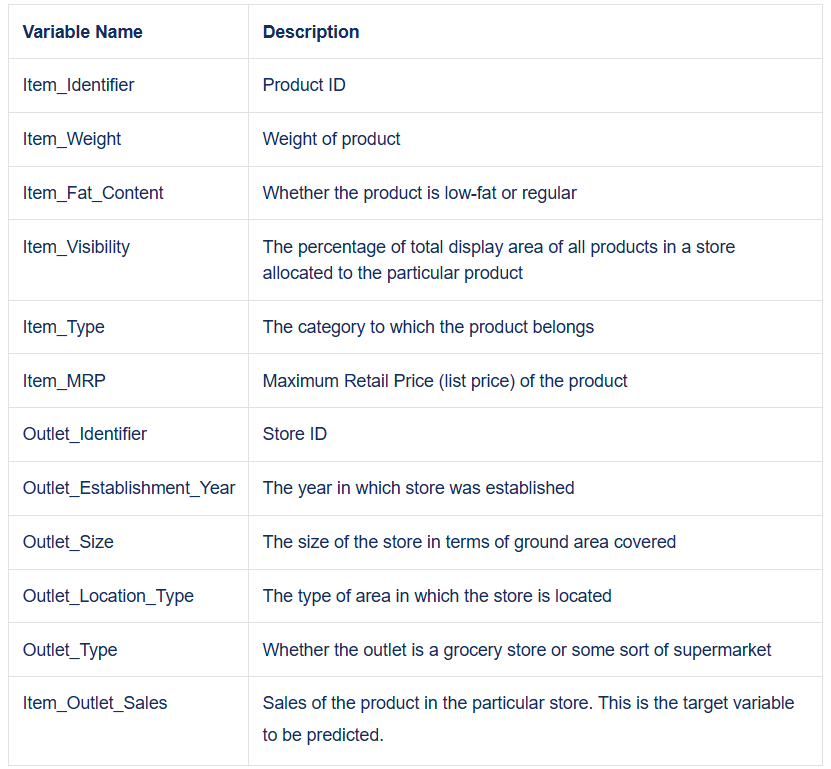

## Load and Inspect Data

### Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config
set_config(transform_output='pandas')

### Loading Data

In [81]:
path='https://docs.google.com/spreadsheets/d/e/2PACX-1vR6AvAZumX2EE8diEPYfNdktYpa8cELog1Iv_SL7EIFj_DIVxnGwq5liujvJ1GTQry9NDkFsISbeWaE/pub?output=csv'
df=pd.read_csv(path)
df_copy=df.copy()

# Drop Item_Identifier and Outlet_Identifier from the full DataFrame before splitting
df.drop(columns=['Item_Identifier','Outlet_Identifier'], inplace=True)
df_copy.drop(columns=['Item_Identifier','Outlet_Identifier'], inplace=True)

# Replace inconsistent Item_Fat_Content values in the full DataFrame before splitting
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'LF':'Low Fat',
                                             "low fat":'Low Fat',
                                             'reg':'Regular'})
df_copy['Item_Fat_Content']=df_copy['Item_Fat_Content'].replace({'LF':'Low Fat',
                                             "low fat":'Low Fat',
                                             'reg':'Regular'})


In [4]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### Train test split

In [ ]:
# target column
y= df['Item_Outlet_Sales']
X= df.drop(columns='Item_Outlet_Sales')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

- Ordinal: Outet size only
- Nominal:  Everything Else
- Numeric: The rest of the df

## Clean Data

### Drop ID's
- ID's dont help in the data analysis, so why keep?

In [82]:
# ID columns are now dropped from the full DataFrame before the split. This step is redundant.

### Dropping ID's for X_test

In [63]:
# ID columns are now dropped from the full DataFrame before the split. This step is redundant.

### Duplicated Rows

In [7]:
# check for duplicated data
duplicated_rows=df.duplicated()
duplicated_rows.sum()

np.int64(0)

- there are no duplicated values



### Unique Identifiers

In [67]:
# number of unique values for each column in X_train
print("Unique values in X_train:")
X_train.nunique()

print("\nUnique values in X_test:")
X_test.nunique()

Unique values in X_train:

Unique values in X_test:


,0
Item_Weight,356
Item_Fat_Content,2
Item_Visibility,1997
Item_Type,16
Item_MRP,1931
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3
Outlet_Type,4


In [68]:
# percentage of unique values in each column for X_train
print("Percentage of unique values in X_train:")
X_train.nunique() / len(X_train) * 100

print("\nPercentage of unique values in X_test:")
X_test.nunique() / len(X_test) * 100

Percentage of unique values in X_train:

Percentage of unique values in X_test:


,0
Item_Weight,16.705772
Item_Fat_Content,0.093853
Item_Visibility,93.711872
Item_Type,0.750821
Item_MRP,90.614735
Outlet_Establishment_Year,0.422337
Outlet_Size,0.140779
Outlet_Location_Type,0.140779
Outlet_Type,0.187705


### Missing Values
- Checking for NaN rows:

In [87]:
# see columns and rows where NaN is present in X_train
X_train.isna()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
4776,False,False,False,False,False,False,False,False,False
7510,False,False,False,False,False,False,False,False,False
5828,False,False,False,False,False,False,False,False,False
5327,False,False,False,False,False,False,False,False,False
4810,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...
5734,False,False,False,False,False,False,True,False,False
5191,False,False,False,False,False,False,True,False,False
5390,False,False,False,False,False,False,True,False,False
860,False,False,False,False,False,False,True,False,False


In [88]:
# check how many rows in each column of X_train has a missing value
null_sums=X_train.isna().sum()
null_sums

,0
Item_Weight,1107
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Establishment_Year,0
Outlet_Size,1812
Outlet_Location_Type,0
Outlet_Type,0


In [89]:
# check the percentage of null values in X_train
null_percent=null_sums/len(X_train)*100
null_percent[null_percent>0]

,0
Item_Weight,17.318523
Outlet_Size,28.347935


- 17.16% from Weight column has missing values
- 28.27% from Store size has missing value

#### Inspect Outlet Size

In [72]:
# filter categorical features from X_train
cat_cols=X_train.select_dtypes('object').columns

# filter numerical features from X_train
num_cols=X_train.select_dtypes('number').columns

In [73]:
X_train['Outlet_Size'].value_counts(dropna=False)

,count
Outlet_Size,
Medium,2103
NaN,1812
Small,1788
High,689


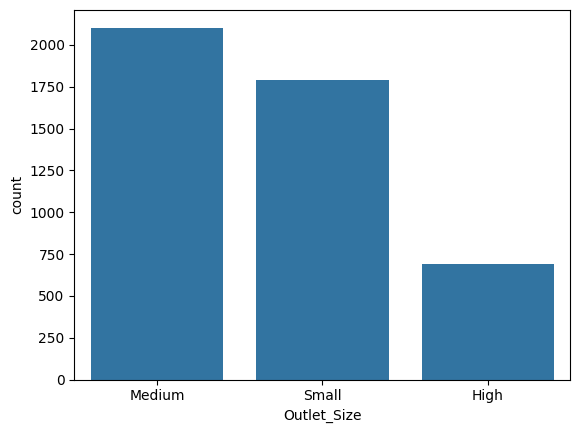

In [60]:
ax=sns.countplot(data=X_train, x='Outlet_Size')

- This graph shows that there are over 2000 Medium and Small Outlets Size while there are less than 1000 High Outlet size.

- Since Outlet_Size is a categorical feature with a large percentage of missing values (~28%):
  - dropping rows would result in significant data loss.
  - Filling with the most frequent category could introduce bias into the distribution.
  - Therefore, replacing missing values with "MISSING" is the most appropriate strategy because it preserves the data

In [65]:
# The Outlet_Size missing values are handled by the Ordinal pipeline. This manual fill is redundant.
# df_copy['Outlet_Size']=df_copy['Outlet_Size'].fillna('MISSING')

# check for applied changes (on df_copy for historical context if needed, but not impacting X_train/X_test)
df_copy['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
MISSING,2410
Small,2388
High,932


#### Inspecting Item Weight

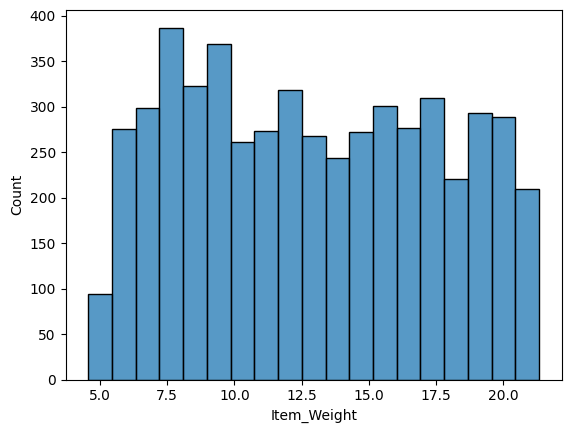

In [59]:
ax = sns.histplot(data=X_train,x='Item_Weight')

- Median is preferred because it is less affected by outliers and preserves the distribution better than using -1 or dropping rows.

- Since Item Weight is a numeric feature, missing values were filled using the median because it is less affected by outliers and helps preserve the overall distribution of the data.

In [66]:
# The Item_Weight missing values are handled by the Numeric pipeline. This manual fill is redundant.
# df_copy['Item_Weight']=df_copy['Item_Weight'].fillna(df['Item_Weight'].median())
# # check if they were filled (on df_copy for historical context if needed, but not impacting X_train/X_test)
# df_copy.isna().sum()

Before filling number columns with placeholder, check describe()

In [86]:
cat_cols_df=X_train.select_dtypes('object').columns
num_cols_df=X_train.select_dtypes('number').columns

In [90]:
# summary of num cols in X_train
for col in num_cols_df:
  print(f'summary of {col}: ')
  print(X_train[col].describe())
  print("\n")

summary of Item_Weight: 
count    5285.000000
mean       12.904458
std         4.637034
min         4.555000
25%         8.895000
50%        12.650000
75%        17.000000
max        21.350000
Name: Item_Weight, dtype: float64


summary of Item_Visibility: 
count    6392.000000
mean        0.066007
std         0.051131
min         0.000000
25%         0.027027
50%         0.054152
75%         0.094618
max         0.328391
Name: Item_Visibility, dtype: float64


summary of Item_MRP: 
count    6392.000000
mean      141.980400
std        62.629276
min        31.290000
25%        94.146200
50%       144.110200
75%       186.900300
max       266.888400
Name: Item_MRP, dtype: float64


summary of Outlet_Establishment_Year: 
count    6392.000000
mean     1997.857165
std         8.392300
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64




nothing needs to be addressed, so we fill all null values in num_cols with -1 placeholder:

### Consistent Values

Check each string column's value counts for inconsistent values:


In [75]:
# loop through each categorical/string column in X_train
for col in cat_cols_df:
  print(f'value counts of {col}: ')
  print(X_train[col].value_counts())
  print("\n")

value counts of Item_Fat_Content: 
Item_Fat_Content
Low Fat    4129
Regular    2263
Name: count, dtype: int64


value counts of Item_Type: 
Item_Type
Fruits and Vegetables    948
Snack Foods              906
Household                695
Frozen Foods             632
Dairy                    507
Canned                   481
Baking Goods             478
Health and Hygiene       390
Soft Drinks              331
Meat                     302
Breads                   175
Hard Drinks              169
Others                   130
Starchy Foods            122
Breakfast                 84
Seafood                   42
Name: count, dtype: int64


value counts of Outlet_Size: 
Outlet_Size
Medium    2103
Small     1788
High       689
Name: count, dtype: int64


value counts of Outlet_Location_Type: 
Outlet_Location_Type
Tier 3    2531
Tier 2    2106
Tier 1    1755
Name: count, dtype: int64


value counts of Outlet_Type: 
Outlet_Type
Supermarket Type1    4166
Grocery Store         799
Supermarket Type

This column has incosistent values:
- Fat Content: LF, reg, low fat

In [76]:
# check for inconsistent values in X_train
X_train['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,4129
Regular,2263


In [64]:
# Item_Fat_Content values are now corrected in the full DataFrame before the split. This step is redundant.
# X_train['Item_Fat_Content']=X_train['Item_Fat_Content'].replace({'LF':'Low Fat',
#                                              "low fat":'Low Fat',
#                                              'reg':'Regular'})
# X_test['Item_Fat_Content']=X_test['Item_Fat_Content'].replace({'LF':'Low Fat',
#                                              "low fat":'Low Fat',
#                                              'reg':'Regular'})

# Confirm applied changes on X_train (now reflecting pre-split cleaning)
X_train['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,4129
Regular,2263


### Describe Numeric Data
- min, max, mean

In [91]:
# get numeric columns from X_train
num_cols_df=X_train.select_dtypes('number').columns

# use the describe method and filter using .loc() on X_train
X_train[num_cols_df].describe().loc[['min','max','mean']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
min,4.555000,0.000000,31.2900,1985.000000
max,21.350000,0.328391,266.8884,2009.000000
mean,12.904458,0.066007,141.9804,1997.857165


## Feature Inspection
- Exploratory Visuals & Analysis

In [78]:
# view X_train data
X_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
4776,16.350,Low Fat,0.029565,Household,256.4646,2009,Medium,Tier 3,Supermarket Type2
7510,15.250,Regular,0.000000,Snack Foods,179.7660,2009,Medium,Tier 3,Supermarket Type2
5828,12.350,Regular,0.158716,Meat,157.2946,1999,Medium,Tier 1,Supermarket Type1
5327,7.975,Low Fat,0.014628,Baking Goods,82.3250,2004,Small,Tier 2,Supermarket Type1
4810,19.350,Low Fat,0.016645,Frozen Foods,120.9098,2002,NaN,Tier 2,Supermarket Type1


ax=X_train.hist(figsize=(12,10));

In [83]:
# ax=df[num_cols].hist(figsize=(12,10));
# This cell was using the old 'df' for plotting numerical histograms.
# The relevant data is now in X_train/y_train after the split and initial cleaning.
# The previous cell `gdVL3JvuhTuv` already plots histograms for X_train's numeric columns.
# To avoid confusion and ensure consistency, I'm commenting this out as it's potentially redundant or misleading in the new workflow.

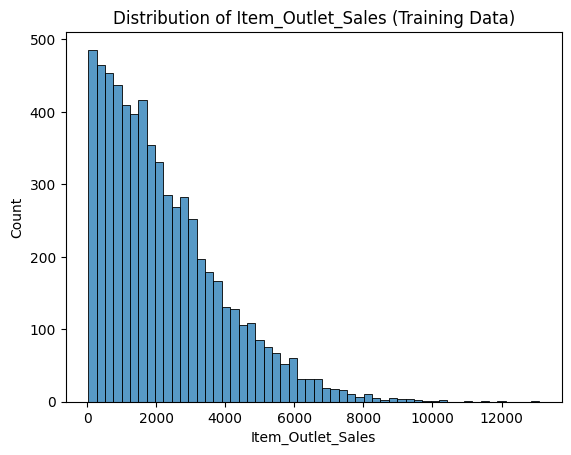

In [79]:
# item outlet sales (from y_train)
ax= sns.histplot(x=y_train)
ax.set_title("Distribution of Item_Outlet_Sales (Training Data)");

- Most items have low visibility.
- Most sales are low, with a few very high sales.
- Item weights are spread out, but many are around 11–13,
  - because we filled the null values with median earlier
- Retail prices vary a lot.
- Outlet establishment years occur at specific years only.

### Boxplot for numeric columns

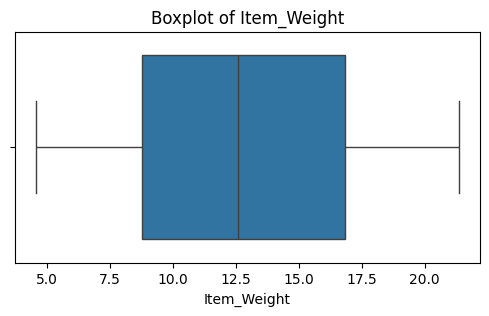

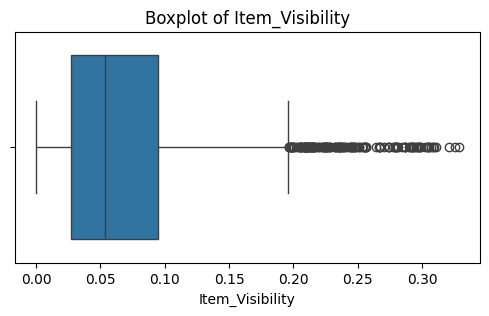

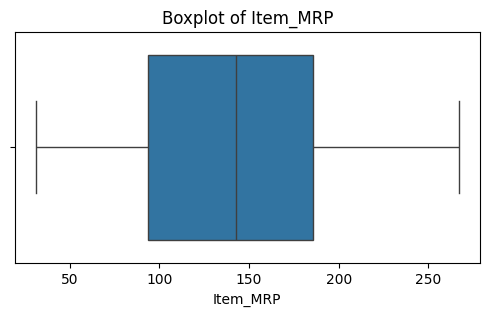

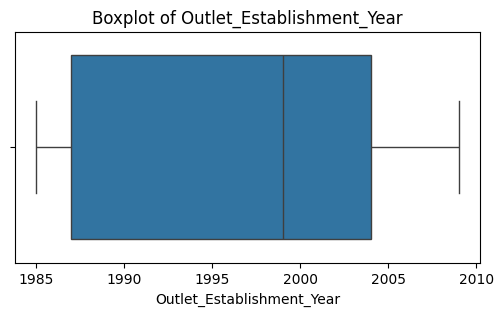

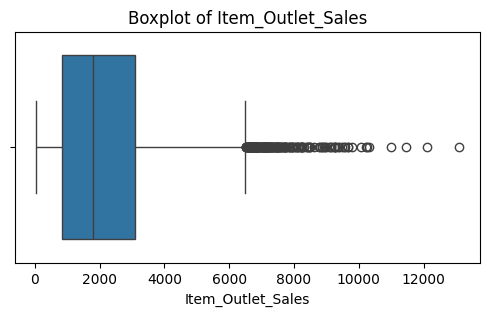

In [28]:
for col in num_cols_df:
    plt.figure(figsize=(6,3))
    ax = sns.boxplot(x=X_train[col])
    ax.set_title(f"Boxplot of {col}")

What we notice from the boxplots:

- Item_Visibility has many outliers (many unusually high values).
- Item_Outlet_Sales also has many high outliers.
- Item_Weight and Maximum Retail Price are more evenly spread.
- Bigger boxes mean more spread in the middle 50% of the data.

### Countplots for Categorical Columns

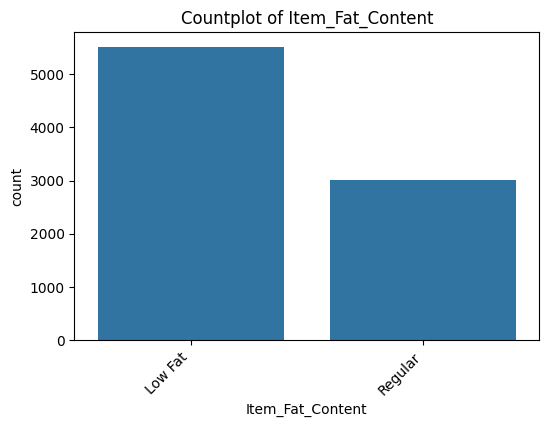

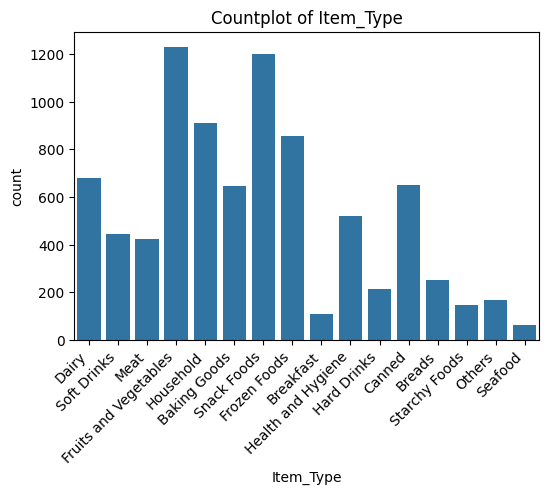

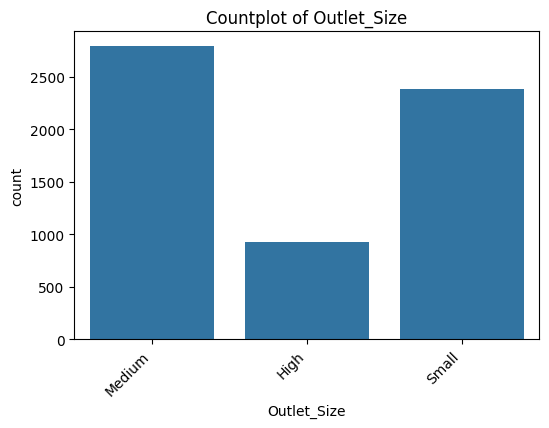

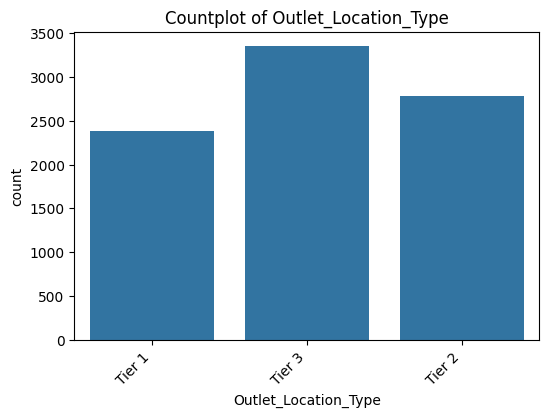

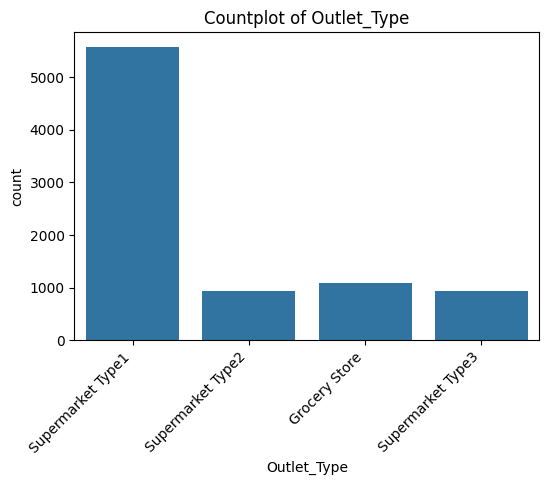

In [29]:
for col in cat_cols_df:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(data=X_train, x=col)
    ax.set_title(f"Countplot of {col}")
    plt.xticks(rotation=45, ha='right');

What we notice from the countplots:

- Low Fat items are more common than Regular items.
- Fruits and Vegetables and Snack Foods are the most common item types.
- Seafood and Breakfast items are the least common.
- Most outlets are Medium or Small in size.
- Tier 3 locations have the most outlets.
- Supermarket Type1 is much more common than the other outlet types.

### Correlation Heatmap


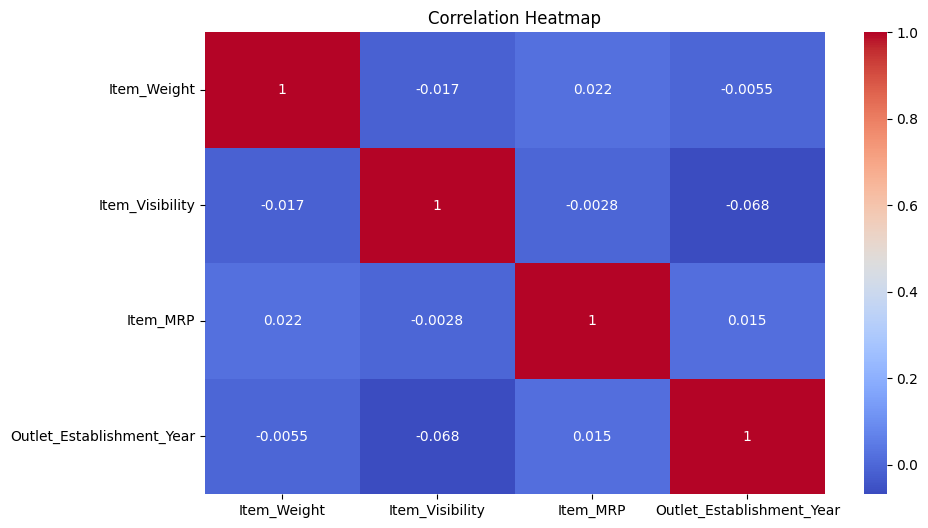

In [92]:
corr = X_train.corr(numeric_only=True)
plt.figure(figsize=(10,6))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title("Correlation Heatmap");

### Regression Plot: Maximum Retail Price & Item Outlet Sales

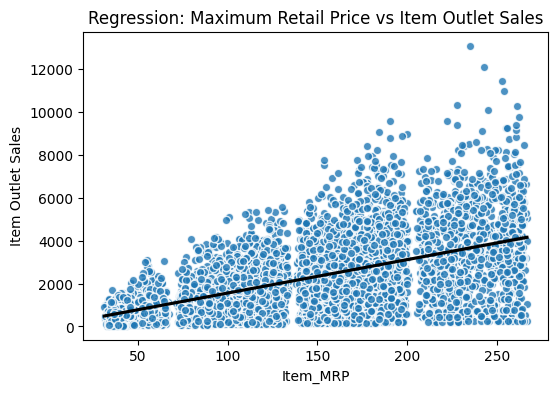

In [85]:
plt.figure(figsize=(6,4))
line_kws = dict(color='black')
scatter_kws = dict(edgecolor='white')

# To correctly plot Item_MRP vs Item_Outlet_Sales, we need to combine X_train and y_train for the plot.
# Alternatively, we can ensure the data passed to sns.regplot contains both columns.
# Since y_train is a Series, we can plot against Item_MRP from X_train directly if indices align.

# Create a temporary DataFrame for plotting if necessary, or ensure direct access
plot_df = pd.DataFrame({'Item_MRP': X_train['Item_MRP'], 'Item_Outlet_Sales': y_train})

ax = sns.regplot(
    data=plot_df,
    x='Item_MRP',
    y='Item_Outlet_Sales',
    line_kws=line_kws,
    scatter_kws=scatter_kws
)

ax.set(
    xlabel="Item_MRP",
    ylabel="Item Outlet Sales",
    title="Regression: Maximum Retail Price vs Item Outlet Sales"
);

- There is a positive relationship between Maximum Retail Price and Item Outlet Sales. As retail price increases, sales tend to increase as well.

### Countplot of Item Type

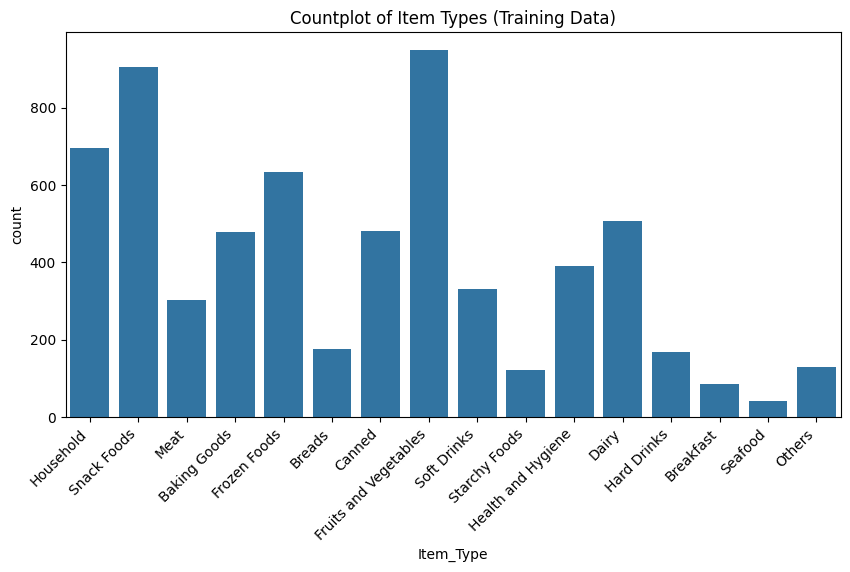

In [80]:
plt.figure(figsize=(10,5))

ax = sns.countplot(data=X_train, x='Item_Type')

ax.set_title("Countplot of Item Types (Training Data)");

plt.xticks(rotation=45, ha='right');

- Fruits and Vegetables and Snack Foods are the most common item categories, while Seafood and Breakfast items appear least frequently.

# inspect X_train
X_train.head()

In [93]:
# inspect data
X_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
4776,16.350,Low Fat,0.029565,Household,256.4646,2009,Medium,Tier 3,Supermarket Type2
7510,15.250,Regular,0.000000,Snack Foods,179.7660,2009,Medium,Tier 3,Supermarket Type2
5828,12.350,Regular,0.158716,Meat,157.2946,1999,Medium,Tier 1,Supermarket Type1
5327,7.975,Low Fat,0.014628,Baking Goods,82.3250,2004,Small,Tier 2,Supermarket Type1
4810,19.350,Low Fat,0.016645,Frozen Foods,120.9098,2002,NaN,Tier 2,Supermarket Type1


In [62]:
# view strings and categorical data
cat_cols_df=X_train.select_dtypes('object').columns
X_train[cat_cols_df]

,Item_Fat_Content,Item_Type,Outlet_Size,Outlet_Location_Type,Outlet_Type
4776,Low Fat,Household,Medium,Tier 3,Supermarket Type2
7510,Regular,Snack Foods,Medium,Tier 3,Supermarket Type2
5828,Regular,Meat,Medium,Tier 1,Supermarket Type1
5327,Low Fat,Baking Goods,Small,Tier 2,Supermarket Type1
4810,Low Fat,Frozen Foods,NaN,Tier 2,Supermarket Type1
...,...,...,...,...,...
5734,Regular,Fruits and Vegetables,NaN,Tier 3,Grocery Store
5191,Low Fat,Frozen Foods,NaN,Tier 2,Supermarket Type1
5390,Low Fat,Health and Hygiene,NaN,Tier 2,Supermarket Type1
860,Low Fat,Snack Foods,NaN,Tier 2,Supermarket Type1


### Ordinal Pipleline

In [36]:
# see value counts for possible ordinal features
ord_cols=['Outlet_Size']
X_train[ord_cols].value_counts(dropna=False)

,count
Outlet_Size,
Medium,2103
NaN,1812
Small,1788
High,689


In [37]:
# order cats
size_order=['MISSING','Small','Medium','High']
# Pipeline
ord_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='MISSING'),
  OrdinalEncoder(categories=[size_order]),
  StandardScaler()
)
ord_tuple = ('Ordinal', ord_pipe, ord_cols)

ord_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='MISSING', strategy='constant')),
                ('ordinalencoder',
                 OrdinalEncoder(categories=[['MISSING', 'Small', 'Medium',
                                             'High']])),
                ('standardscaler', StandardScaler())])

### Nominal

In [44]:
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns
ohe_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='NA'),
  OneHotEncoder(sparse_output=False, handle_unknown='ignore')
)

ohe_tuple = ('Categorical', ohe_pipe, ohe_cols)
ohe_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='NA', strategy='constant')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

### Numeric

In [43]:
num_cols_train= make_column_selector(dtype_include="number")
num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
num_tuple = ('Numeric', num_pipe, num_cols_train)

num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

### Creating Preprocessor

In [48]:
preprocessor = ColumnTransformer(
  [num_tuple, ord_tuple, ohe_tuple],
  verbose_feature_names_out=False
)

### Model Evaluation Function

In [51]:

def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = mse ** 0.5
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  y_train_pred = reg.predict(X_train)

  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  y_test_pred = reg.predict(X_test)
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    results_df = results_df.set_index('Label')
    results_df.index.name=None
    return results_df.round(3)

## Model: Linear Regression

In [49]:
# linear regression

linreg_pipe = make_pipeline(preprocessor, LinearRegression())

# Fit on raw training data
linreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e70fbf05430>),
                                                 ('Ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 stra...
                                                  ['Outlet_Size']),
                                                 ('Categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Location_Type', 'Outlet_Type'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [52]:
evaluate_regression(linreg_pipe, X_train, y_train, X_test, y_test, output_frame=True)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 847.162
- MSE = 1,298,027.006
- RMSE = 1,139.310
- R^2 = 0.561

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 804.841
- MSE = 1,195,846.760
- RMSE = 1,093.548
- R^2 = 0.567


,MAE,MSE,RMSE,R^2
Training Data,847.162,1298027.006,1139.310,0.561
Test Data,804.841,1195846.760,1093.548,0.567


- The model does not appear to be overfit or underfit.
- The training R^2 (0.561) and test R^2 (0.567) are very close, indicating that it generalizes well to unseen data. However, since both values are only around 0.56, the model provides a moderate fit and could potentially be improved with better features or a more complex model

## Model: Random Forest

In [54]:
rf = RandomForestRegressor(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 297.189
- MSE = 184,006.060
- RMSE = 428.959
- R^2 = 0.938

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 771.873
- MSE = 1,240,416.523
- RMSE = 1,113.740
- R^2 = 0.550


- The Random Forest model is overfitting. Its training R^2 score (0.938) is much higher than its test (0.550), meaning that it has memorized the training data and does not generalize as well to new data

- Although the Random Forest has a slightly lower MAE, the Linear Regression model has better overall test performance because it has:
  - Lower MSE
  - Lower RMSE
  - Higher R²

### Tuning with GridCV

In [57]:
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('Numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x7e70fbf05430>),
                                   ('Ordinal',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='MISSING',
                                                                   strategy='constant')),
                                                    ('ordinalencoder',
                                                     O...
                                                    (

In [94]:
params = {
    'randomforestregressor__max_depth': [None, 10, 15, 20],
    'randomforestregressor__n_estimators': [ 100, 150, 200],
    'randomforestregressor__min_samples_leaf': [1, 2, 4],
    'randomforestregressor__max_features': ['sqrt', 'log2', None],
    'randomforestregressor__oob_score': [True, False]
}

# 4x3x3x3x2 = 216 combinations x 3 folds = 648 fits

gridsearch = GridSearchCV(rf_pipe, params, n_jobs=-1, cv=3, verbose=1)
gridsearch.fit(X_train, y_train)

print('\n',gridsearch.best_params_,'\n')

# Best model
best_rf = gridsearch.best_estimator_
evaluate_regression(best_rf, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 216 candidates, totalling 648 fits

 {'randomforestregressor__max_depth': 10, 'randomforestregressor__max_features': None, 'randomforestregressor__min_samples_leaf': 1, 'randomforestregressor__n_estimators': 150, 'randomforestregressor__oob_score': True} 

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 644.024
- MSE = 827,247.231
- RMSE = 909.531
- R^2 = 0.720

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 740.365
- MSE = 1,133,816.367
- RMSE = 1,064.808
- R^2 = 0.589
